# Direct Limb Darkening from Intensity-Based Emission

Last update: August 2026, for ExoJAX 2.6.0

This tutorial shows how to derive quadratic limb-darkening coefficients directly from the angular intensities computed by the intensity-based emission solver. The workflow follows the standard `get_started` emission example: CO molecular absorption plus H2-H2 CIA continuum opacity.

The key point is that `ArtEmisPure` with `rtsolver="ibased"` internally computes emergent intensities at Gauss-Legendre quadrature points. ExoJAX can expose those intensities as `I(mu, nu)` and fit the quadratic law

```text
I(mu) / I(1) = 1 - u1 (1 - mu) - u2 (1 - mu)^2
```

without treating `u1` and `u2` as free post-processing parameters.

This notebook assumes the same local databases as the getting-started emission tutorials:

- `.database/CO/12C-16O/Li2015`
- `.database/H2-H2_2011.cia`

Use `nstream >= 6` for a quadratic fit because the upward hemisphere has `N' = nstream / 2` quadrature points.

In [1]:
from jax import config
config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

## 1. Build the Same CO + CIA Emission Model as `get_started`

Use a moderate grid so that the tutorial runs quickly while keeping the setup close to the standard emission workflow.

In [2]:
from exojax.utils.grids import wavenumber_grid

Nnus = 20000
nu_grid, wav, resolution = wavenumber_grid(
    22920.0,
    23100.0,
    Nnus,
    unit="AA",
    xsmode="premodit",
    wavelength_order="ascending",
)
print(f"Nnu = {len(nu_grid)}, resolution = {resolution:.1f}")

xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  ascending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Nnu = 20000, resolution = 2556525.8


/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(


In [3]:
from exojax.database.exomol.api import MdbExomol
from exojax.opacity import OpaPremodit

mdb = MdbExomol(".database/CO/12C-16O/Li2015", nurange=nu_grid)
molmass = mdb.molmass
snapshot = mdb.to_snapshot()
del mdb

opa = OpaPremodit.from_snapshot(
    snapshot,
    nu_grid,
    auto_trange=(500.0, 1500.0),
    dit_grid_resolution=1.0,
)

radis== 0.15.2
HITRAN exact name= (12C)(16O)
radis engine =  pytables
		 => Downloading from http://www.exomol.com/db/CO/12C-16O/Li2015/12C-16O__Li2015.def


/home/kawahara/exojax/src/exojax/database/_common/radis_adapter.py:63: UserWarning: The current version of radis does not support broadf_download (requires >=0.16).
  warnings.warn(msg, UserWarning)
/home/kawahara/exojax/src/exojax/utils/molname.py:197: FutureWarning: e2s will be replaced to exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/molname.py:91: FutureWarning: exojax.utils.molname.exact_molname_exomol_to_simple_molname will be replaced to radis.api.exomolapi.exact_molname_exomol_to_simple_molname.
  warnings.warn(


		 => Downloading from http://www.exomol.com/db/CO/12C-16O/Li2015/12C-16O__Li2015.pf
		 => Downloading from http://www.exomol.com/db/CO/12C-16O/Li2015/12C-16O__Li2015.states.bz2
		 => Downloading from http://www.exomol.com/db/CO/12C-16O/12C-16O__H2.broad
		 => Downloading from http://www.exomol.com/db/CO/12C-16O/12C-16O__He.broad
		 => Downloading from http://www.exomol.com/db/CO/12C-16O/12C-16O__air.broad
Note: Caching states data to the pytables format. After the second time, it will become much faster.
Molecule:  CO
Isotopologue:  12C-16O
Background atmosphere:  H2
ExoMol database:  None
Local folder:  .database/CO/12C-16O/Li2015
Transition files: 
	 => File 12C-16O__Li2015.trans
		 => Downloading from http://www.exomol.com/db/CO/12C-16O/Li2015/12C-16O__Li2015.trans.bz2
		 => Caching the *.trans.bz2 file to the pytables (*.h5) format. After the second time, it will become much faster.
		 => You can deleted the 'trans.bz2' file by hand.
Broadener:  H2
Broadening code level: a0
defaul

/home/kawahara/miniconda3/lib/python3.12/site-packages/radis-0.15.2-py3.12.egg/radis/api/exomolapi.py:685: AccuracyWarning: The default broadening parameter (alpha = 0.07 cm^-1 and n = 0.5) are used for J'' > 80 up to J'' = 152
  warnings.warn(
/home/kawahara/exojax/src/exojax/opacity/premodit/core.py:28: UserWarning: dit_grid_resolution is not None. Ignoring broadening_parameter_resolution.
  warnings.warn(


max value of  ngamma_ref_grid : 24.16668486178811
min value of  ngamma_ref_grid : 20.063716461253346
ngamma_ref_grid grid : [20.06371498 24.16668701]
max value of  n_Texp_grid : 0.658
min value of  n_Texp_grid : 0.5
n_Texp_grid grid : [0.49999997 0.65800005]


uniqidx: 0it [00:00, ?it/s]

Premodit: Twt= 1108.7151960064205 K Tref= 570.4914318566549 K
Making LSD: [####################] 100%


In [4]:
from exojax.rt import ArtEmisPure
from exojax.utils.astrofunc import gravity_jupiter

art = ArtEmisPure(
    pressure_top=1.0e-5,
    pressure_btm=1.0e1,
    nlayer=100,
    nu_grid=nu_grid,
    rtsolver="ibased",
    nstream=8,
)
art.change_temperature_range(400.0, 1500.0)

Tarr = art.clip_temperature(art.powerlaw_temperature(900.0, 0.1))
mmr_profile = art.constant_mmr_profile(1.0e-5)
gravity = gravity_jupiter(1.0, 10.0)

rtsolver:  ibased
Intensity-based n-stream solver, isothermal layer (e.g. NEMESIS, pRT like)


In [5]:
from exojax.database.contdb import CdbCIA
from exojax.opacity import OpaCIA

cdb = CdbCIA(".database/H2-H2_2011.cia", nurange=nu_grid)
opacia = OpaCIA(cdb, nu_grid=nu_grid)

xsmatrix = opa.xsmatrix(Tarr, art.pressure)
logacia_matrix = opacia.logacia_matrix(Tarr)

dtau_co = art.opacity_profile_xs(xsmatrix, mmr_profile, molmass, gravity)
vmrH2 = 0.855
mmw = 2.33
dtau_cia = art.opacity_profile_cia(logacia_matrix, Tarr, vmrH2, vmrH2, mmw, gravity)
dtau = dtau_co + dtau_cia

Load CIA:  H2-H2


## 2. Compute Flux and Limb Darkening in One RT Pass

`run_with_limb_darkening` runs the intensity-based RT once. It returns the flux and wavelength-dependent quadratic coefficients `u1(nu)` and `u2(nu)` derived from the same `I(mu, nu)` used for the flux integral.

In [6]:
flux, u1_nu, u2_nu = art.run_with_limb_darkening(dtau, Tarr)
flux_check = art.run(dtau, Tarr)
print("max relative flux difference =", np.max(np.abs(flux / flux_check - 1.0)))
print("u1 shape =", u1_nu.shape, "u2 shape =", u2_nu.shape)

max relative flux difference = 0.0
u1 shape = (20000,) u2 shape = (20000,)


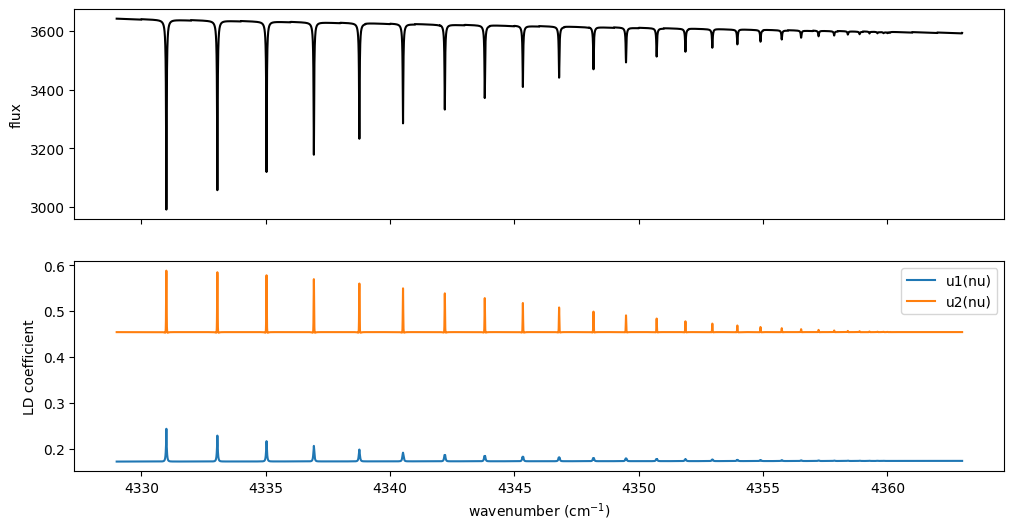

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(nu_grid, flux, color="black")
axes[0].set_ylabel("flux")
axes[1].plot(nu_grid, u1_nu, label="u1(nu)")
axes[1].plot(nu_grid, u2_nu, label="u2(nu)")
axes[1].set_xlabel("wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("LD coefficient")
axes[1].legend()
plt.show()

The existing rigid-rotation operator uses scalar `u1` and `u2`, because it assumes one rotation kernel over the modeled spectral segment. A practical first-order choice is to flux-weight the wavelength-dependent coefficients over the segment.

In [8]:
from exojax.postproc.limb_darkening import average_limb_darkening_coefficients
from exojax.postproc.specop import SopRotation

u1_scalar, u2_scalar = average_limb_darkening_coefficients(u1_nu, u2_nu, flux)
print("flux-weighted u1, u2 =", float(u1_scalar), float(u2_scalar))

sop_rot = SopRotation(nu_grid, vsini_max=100.0)
vsini = 10.0
flux_rot = sop_rot.rigid_rotation(flux, vsini, u1_scalar, u2_scalar)

flux-weighted u1, u2 = 0.1729588823832821 0.454857167340709


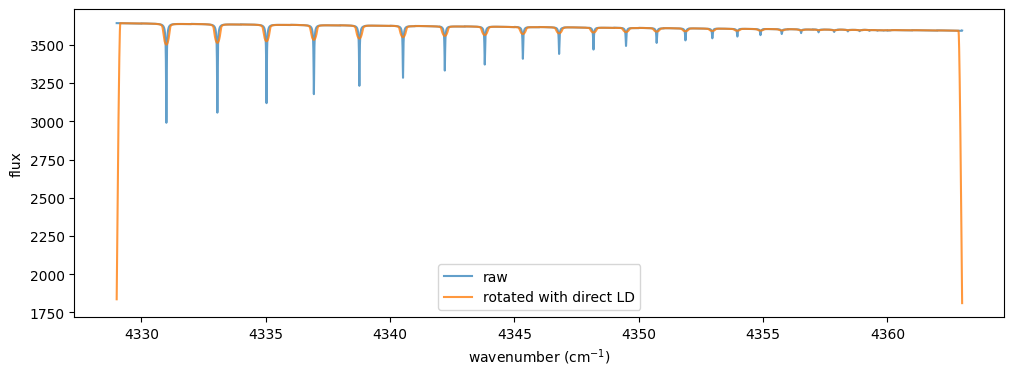

In [9]:
fig = plt.figure(figsize=(12, 4))
plt.plot(nu_grid, flux, label="raw", alpha=0.7)
plt.plot(nu_grid, flux_rot, label="rotated with direct LD", alpha=0.8)
plt.xlabel("wavenumber (cm$^{-1}$)")
plt.ylabel("flux")
plt.legend()
plt.show()

## 3. CKD Emission

For CKD, `run_ckd_with_limb_darkening` returns band fluxes and band-wise limb-darkening coefficients. The example below applies CKD to the CO opacity. The CIA optical depth is sampled at the band centers and broadcast over the CKD g-ordinates before being added.

In [10]:
from exojax.opacity import OpaCKD

opa_ckd = OpaCKD(opa, Ng=16, band_width=0.5)
T_grid = np.linspace(float(np.min(Tarr)), float(np.max(Tarr)), 10)
P_grid = np.logspace(np.log10(float(np.min(art.pressure))), np.log10(float(np.max(art.pressure))), 10)
opa_ckd.precompute_tables(T_grid, P_grid)

xs_ckd = opa_ckd.xstensor_ckd(Tarr, art.pressure)
dtau_co_ckd = art.opacity_profile_xs_ckd(xs_ckd, mmr_profile, molmass, gravity)

# Add CIA at the CKD band centers. jnp.interp operates along one vector,
# so map it over atmospheric layers.
dtau_cia_bands = jnp.vstack([
    jnp.interp(opa_ckd.nu_bands, nu_grid, dtau_cia_layer)
    for dtau_cia_layer in dtau_cia
])
dtau_ckd = dtau_co_ckd + dtau_cia_bands[:, None, :]

flux_ckd, u1_ckd, u2_ckd = art.run_ckd_with_limb_darkening(
    dtau_ckd,
    Tarr,
    opa_ckd.ckd_info.weights,
    opa_ckd.nu_bands,
)
print("CKD flux shape =", flux_ckd.shape)
print("CKD u1 shape =", u1_ckd.shape)

Generated g-grid: 16 points, range [0.0053, 0.9947]
Processing 68 spectral bands...
  Band 1: [4329.0, 4329.5] cm⁻¹, 295 frequencies
  Band 2: [4329.5, 4330.0] cm⁻¹, 294 frequencies
  Band 3: [4330.0, 4330.5] cm⁻¹, 294 frequencies
  Band 4: [4330.5, 4331.0] cm⁻¹, 294 frequencies
  Band 5: [4331.0, 4331.5] cm⁻¹, 294 frequencies
  Band 6: [4331.5, 4332.0] cm⁻¹, 294 frequencies
  Band 7: [4332.0, 4332.5] cm⁻¹, 294 frequencies
  Band 8: [4332.5, 4333.0] cm⁻¹, 294 frequencies
  Band 9: [4333.0, 4333.5] cm⁻¹, 294 frequencies
  Band 10: [4333.5, 4334.0] cm⁻¹, 295 frequencies
  Band 11: [4334.0, 4334.5] cm⁻¹, 294 frequencies
  Band 12: [4334.5, 4335.0] cm⁻¹, 294 frequencies
  Band 13: [4335.0, 4335.5] cm⁻¹, 294 frequencies
  Band 14: [4335.5, 4336.0] cm⁻¹, 294 frequencies
  Band 15: [4336.0, 4336.5] cm⁻¹, 294 frequencies
  Band 16: [4336.5, 4337.0] cm⁻¹, 294 frequencies
  Band 17: [4337.0, 4337.5] cm⁻¹, 294 frequencies
  Band 18: [4337.5, 4338.0] cm⁻¹, 294 frequencies
  Band 19: [4338.0, 4338.

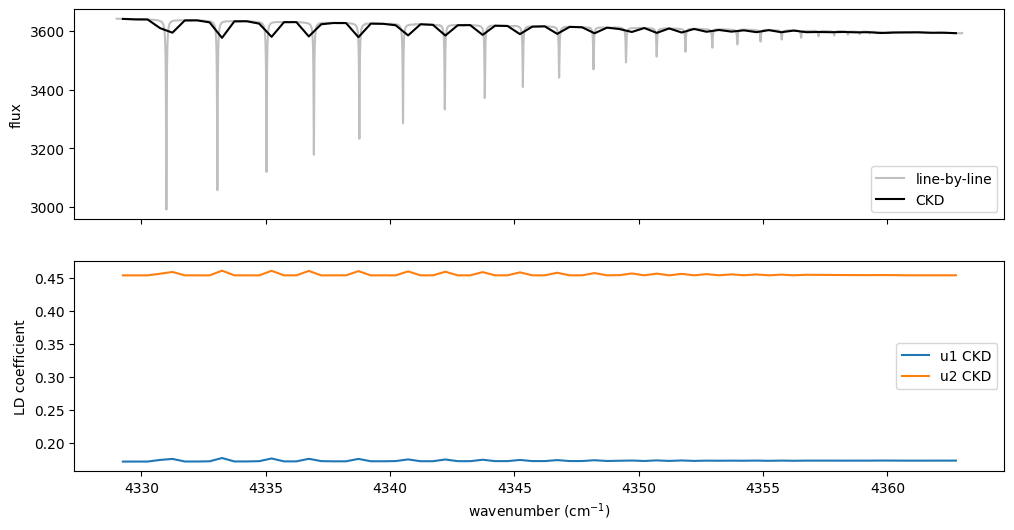

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(nu_grid, flux, color="gray", alpha=0.5, label="line-by-line")
axes[0].plot(opa_ckd.nu_bands, flux_ckd, color="black", label="CKD")
axes[0].set_ylabel("flux")
axes[0].legend()
axes[1].plot(opa_ckd.nu_bands, u1_ckd, label="u1 CKD")
axes[1].plot(opa_ckd.nu_bands, u2_ckd, label="u2 CKD")
axes[1].set_xlabel("wavenumber (cm$^{-1}$)")
axes[1].set_ylabel("LD coefficient")
axes[1].legend()
plt.show()

## 4. Layer-Wise `OpartEmisPure`

`OpartEmisPure` can derive direct limb darkening as well. The only difference is that the user-supplied layer update function should call `update_layer_intensity` instead of `update_layer`. This stores the `(N_mu, N_nu)` intensity carry while still avoiding a full `(N_layer, N_nu)` opacity matrix.

In [12]:
from exojax.rt import OpartEmisPure
from exojax.rt.layeropacity import single_layer_optical_depth, single_layer_optical_depth_CIA

class OpaLayer:
    def __init__(self, nu_grid, snapshot, molmass):
        self.nu_grid = nu_grid
        self.molmass = molmass
        self.opa_co = OpaPremodit.from_snapshot(
            snapshot,
            self.nu_grid,
            auto_trange=(500.0, 1500.0),
            dit_grid_resolution=1.0,
            allow_32bit=True,
        )
        self.cdb_cia = CdbCIA(".database/H2-H2_2011.cia", nurange=self.nu_grid)
        self.opa_cia = OpaCIA(self.cdb_cia, nu_grid=self.nu_grid)
        self.gravity = gravity_jupiter(1.0, 10.0)
        self.vmrH2 = 0.855
        self.mmw = 2.33

    def __call__(self, params):
        temperature, pressure, dP, mixing_ratio = params
        xsv_co = self.opa_co.xsvector(temperature, pressure)
        dtau_co = single_layer_optical_depth(
            dP, xsv_co, mixing_ratio, self.molmass, self.gravity
        )
        logacia_vector = self.opa_cia.logacia_vector(temperature)
        dtau_cia = single_layer_optical_depth_CIA(
            temperature,
            pressure,
            dP,
            self.vmrH2,
            self.vmrH2,
            self.mmw,
            self.gravity,
            logacia_vector,
        )
        return dtau_co + dtau_cia

In [13]:
opalayer = OpaLayer(nu_grid, snapshot, molmass)
opart = OpartEmisPure(
    opalayer,
    pressure_top=1.0e-5,
    pressure_btm=1.0e1,
    nlayer=100,
    nstream=8,
)
opart.change_temperature_range(400.0, 1500.0)

def layer_update_function_intensity(carry_tauintensity, params):
    carry_tauintensity = opart.update_layer_intensity(carry_tauintensity, params)
    return carry_tauintensity, None

Tarr_opart = opart.clip_temperature(opart.powerlaw_temperature(900.0, 0.1))
mmr_profile_opart = opart.constant_mmr_profile(1.0e-5)
layer_params = [Tarr_opart, opart.pressure, opart.dParr, mmr_profile_opart]

flux_opart, u1_opart, u2_opart = opart.run_with_limb_darkening(
    layer_params,
    layer_update_function_intensity,
)
print("Opart flux shape =", flux_opart.shape)
print("Opart u1 shape =", u1_opart.shape)

default elower grid trange (degt) file version: 2
Robust range: 485.7803992045456 - 1514.171191195336 K
max value of  ngamma_ref_grid : 24.16668486178811
min value of  ngamma_ref_grid : 20.063716461253346
ngamma_ref_grid grid : [20.06371498 24.16668701]
max value of  n_Texp_grid : 0.658
min value of  n_Texp_grid : 0.5
n_Texp_grid grid : [0.49999997 0.65800005]


uniqidx: 0it [00:00, ?it/s]

Premodit: Twt= 1108.7151960064205 K Tref= 570.4914318566549 K
Making LSD: [####################] 100%


Load CIA:  H2-H2
Opart flux shape = (20000,)
Opart u1 shape = (20000,)


## Notes

- `run_intensity` and `run_with_limb_darkening` currently apply to the isothermal-layer `ibased` pure-absorption solver.
- Use `nstream >= 6` for quadratic limb darkening. The default `nstream=8` gives four upward quadrature points.
- `u1(nu)` and `u2(nu)` are wavelength dependent. The current `SopRotation.rigid_rotation` kernel accepts scalar coefficients, so use a representative average when connecting direct LD to the existing rotation postprocess.
- A fully wavelength-dependent rotational integral would require a different operator, because the local spectrum and limb darkening both depend on `mu`.